In [216]:
import scipy as sp
from scipy.integrate import quad
from numpy import exp, sqrt, pi, cos, sin, linspace, zeros, log, log10
import matplotlib.pyplot as plt
from utils import e_r_cpa
from utils import hl2, hl2prime, hl1, hl1prime, e_r_cpa, h_r_cpa, e_r_cpa_numerator, h_r_cpa_numerator, graphene_conductivity
from scipy.special import jv, hankel2, hankel1, yv, jvp, yvp, spherical_jn, spherical_yn, factorial2
from utils import hbar, c, alpha # Plank's constant in eV*s, speed of light in nanometers per second, fine structure constant
tau = 6.4*1e-13 # scattering time in seconds

In [122]:
def alpha_integrand_1(k_p, h):
    k_z = sqrt(1-k_p**2)
    delta = 2*k_z*h
    return (k_p**3/k_z)*(1+exp(1j*delta))**2/exp(1j*delta)

def alpha_integrand_2(k_p, h):
    k_z = sqrt(1-k_p**2)
    delta = 2*k_z*h
    return (k_p**3/k_z)*cos(delta)

def alpha_integrand_3(k_p, h):
    k_z = sqrt(1-k_p**2)
    delta = 2*k_z*h
    return (k_p**3/k_z)*sin(delta)

def alpha_integrand_4(k_p, h):
    k_z = sqrt(k_p**2-1)
    delta = 2*k_z*h
    return (k_p**3/k_z)*exp(-delta)

### We normalize all quantities to the free space wavevector. I.e. $h\rightarrow h k_0, k_\rho\rightarrow k_\rho/k_0, k_z\rightarrow k_z/h$

In [227]:
num_lambda = 100
h_lambdas = linspace(0.001, 2, num_lambda)
alphas_real = zeros(num_lambda)
alphas_imag = zeros(num_lambda)

for (h_lambda_idx, h_lambda) in enumerate(h_lambdas):
    h = 2*pi*h_lambda
    limit = 100000
    integrand_1 = quad(lambda k_p: alpha_integrand_1(k_p, h), 0, 1, limit=limit)[0]
    integrand_2 = quad(lambda k_p: alpha_integrand_2(k_p, h), 0, 1-1e-7, limit=limit)[0]
    integrand_3 = quad(lambda k_p: alpha_integrand_3(k_p, h), 0, 1, limit=limit)[0]
    integrand_4 = quad(lambda k_p: alpha_integrand_4(k_p, h), 1, 10, limit=limit)[0]

    alpha = 1j/(2*pi**2)*1/(integrand_1-integrand_2-1j*integrand_3+1j*integrand_4)
    alphas_real[h_lambda_idx] = alpha.real
    alphas_imag[h_lambda_idx] = alpha.imag

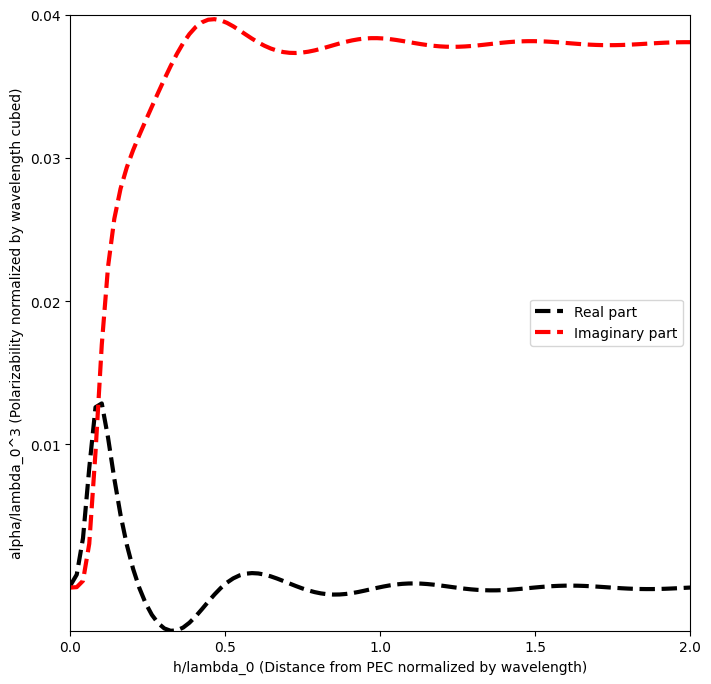

In [236]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(h_lambdas, alphas_real, color="black", linestyle="dashed", linewidth=3, label="Real part")
ax.plot(h_lambdas, alphas_imag, color="red", linestyle="dashed", linewidth=3, label="Imaginary part")
ax.set_xlim(0, 2)
ax.set_ylim(-0.003, 0.04);
ax.set_xlabel("h/lambda_0 (Distance from PEC normalized by wavelength)")
ax.set_ylabel("alpha/lambda_0^3 (Polarizability normalized by wavelength cubed)");
ax.set_yticks([0.01, 0.02, 0.03, 0.04])
ax.set_xticks(linspace(0, 2, 5));
ax.legend();

### Now we try to find the conductivity. We do this by noting that $\alpha=-3\pi i/(\omega/c)^3\times(s-1)$

In [241]:
N = 1000
epsilon = 2 + 0.0j
alphas_real = zeros(N)
x_arr = linspace(0.1, 1, N)
for (x_idx, x) in enumerate(x_arr):
    s = e_r_cpa(1, x, epsilon)
    alpha = -1j*(3*pi)*(s-1)/x**3
    alphas_real[x_idx] = alpha.real

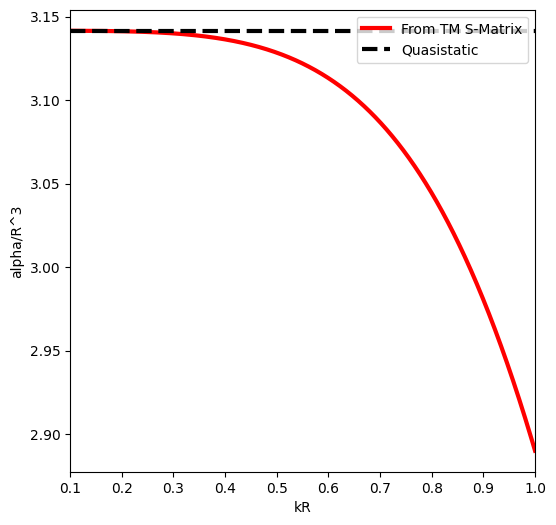

In [253]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(x_arr, alphas_real, label="From TM S-Matrix", color="red", linewidth=3)
ax.hlines([4*pi*(epsilon-1)/(epsilon+2)], x_arr.min(), x_arr.max(), linestyle="dashed", label="Quasistatic", color="black", linewidth=3)
ax.legend()
ax.set_xlabel("kR")
ax.set_ylabel("alpha/R^3")
ax.set_xlim(0.1, 1);

### Now we note that $s=1+\frac{8\pi^2 i}{3}\tilde{\alpha}$, where $\tilde{\alpha}\equiv \alpha/\lambda_0^3$

In [210]:
alpha = alphas_real[-1] + 1j*alphas_imag[-1]
s = 1 + (8*pi**2*1j/3)*alpha

l = 1
epsilon = 2.1 # Permittivity of the sphere
x = 0.1
M = 1000
x = linspace(0.01, 1, M) # Free space kR
m = sqrt(epsilon) # Refractive index
y = x * m # epsilonkR in the cylinder

j_ly = spherical_jn(l, y)
j_lx = spherical_jn(l, x)
y_lx = spherical_yn(l, x)

yjl_prime = spherical_jn(l, y) + y*spherical_jn(l, y, derivative=True)
xjl_prime = spherical_jn(l, x) + x*spherical_jn(l, x, derivative=True)
xyl_prime = spherical_yn(l, x) + x*spherical_yn(l, x, derivative=True)

g_prefac = -yjl_prime * ((xjl_prime + 1j* xyl_prime)*s + (xjl_prime - 1j* xyl_prime))
rhs_1 = epsilon*j_ly*((xjl_prime + 1j* xyl_prime)*s + (xjl_prime - 1j* xyl_prime))
rhs_2 = - yjl_prime * ((j_lx + 1j*y_lx)*s + (j_lx-1j*y_lx))
g = (rhs_1+rhs_2)/g_prefac
sigma = -1j*g*x
sigma_imaginary = sigma.imag
sigma_real = sigma.real

In [220]:
E_F = (hbar/tau)*(sigma_real**2+sigma_imaginary**2)/(4*sigma_real)/alpha;
a = c*tau*x*sigma_real/sigma_imaginary;
hbar_omega = hbar*(sigma_imaginary/sigma_real)*(1/tau)

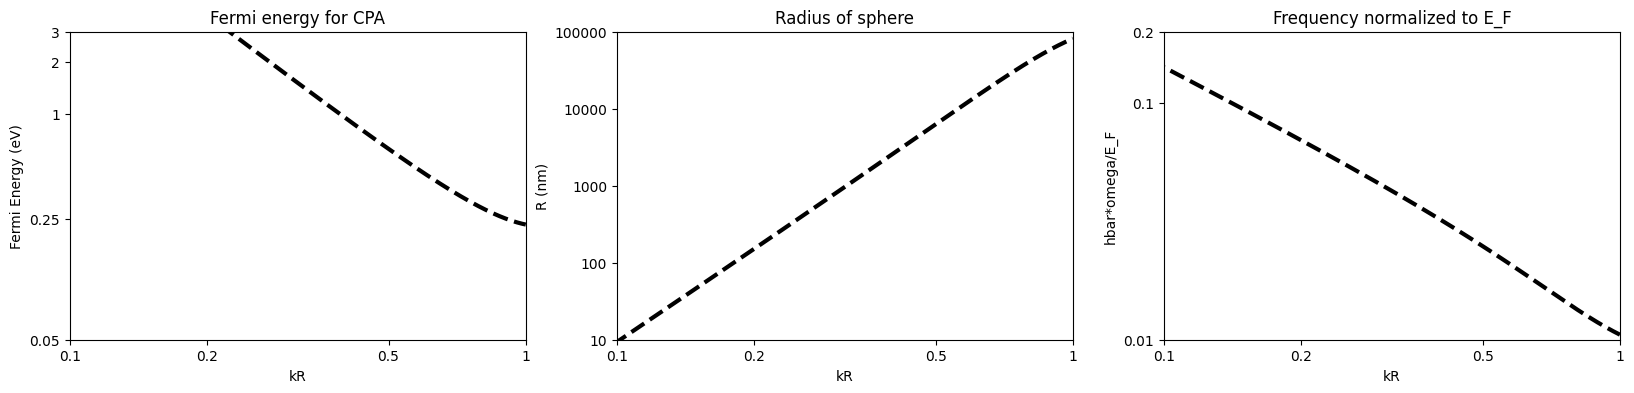

In [225]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 4))
ax1.plot(log10(x), log10(E_F), color="black", linestyle="dashed", linewidth=3)
ax1.set_yticks([log10(0.05), log10(0.25), log10(1), log10(2), log10(3)], [0.05, 0.25, 1, 2, 3])
ax1.set_ylim(log10(0.05), log10(3));
ax1.set_xlim(log10(0.1), log10(1))
ax1.set_xticks([log10(0.1), log10(0.2), log10(0.5), log10(1)], [0.1, 0.2, 0.5, 1])
ax2.set_xticks([log10(0.1), log10(0.2), log10(0.5), log10(1)], [0.1, 0.2, 0.5, 1])
ax3.set_xticks([log10(0.1), log10(0.2), log10(0.5), log10(1)], [0.1, 0.2, 0.5, 1])

ax1.set_xlabel("kR");
ax1.set_ylabel("Fermi Energy (eV)");
ax1.set_title("Fermi energy for CPA");

ax2.plot(log10(x), log10(a), color="black", linestyle="dashed", linewidth=3)
ax2.set_yticks([log10(1e1), log10(1e2), log10(1e3), log10(1e4), log10(1e5)], [10, 100, 1000, 10000, 100000])
ax2.set_ylim(log10(1e1), log10(1e5));
ax2.set_xlim(log10(0.1), log10(1))
ax2.set_xlabel("kR");
ax2.set_ylabel("R (nm)");
ax2.set_title("Radius of sphere");

ax3.plot(log10(x), log10(hbar_omega/E_F), color="black", linestyle="dashed", linewidth=3)
ax3.set_yticks([log10(0.01), log10(0.1), log10(0.2)], [0.01, 0.1, 0.2])
ax3.set_ylim(log10(0.01), log10(0.2));
ax3.set_xlim(log10(0.1), log10(1))
ax3.set_xlabel("kR");
ax3.set_ylabel("hbar*omega/E_F");
ax3.set_title("Frequency normalized to E_F");